# Nuclear Fission Chain Reaction — Monte Carlo Simulation
## Phase 1: Fixed Probability Model (starting off simple)

This notebook simulates a nuclear fission chain reaction using Monte Carlo methods.

### Model Assumptions (Phase 1)
- Reaction starts with a single neutron
- Each neutron has a fixed probability `p` of causing fission
- A fission event releases `n_fission` new neutrons
- No fission → neutron is absorbed (lost)
- `p` is uniform across all neutrons (spatial effects deferred to Phase 2)

### Key Parameter
#### How many neutrons does a single neutron produce in the next generation? We call this **the effective neutron multiplication factor**, or $k_{\text{eff}}$

> **Note:** Fission works by firing a neutron at a nucleus (the core of an atom, containing protons and neutrons). The neutron is absorbed, destabilizing the nucleus and causing it to split apart — releasing energy and new neutrons in the process.

In [3]:
from IPython.display import HTML, display

display(HTML("""
<div style="text-align: center;">
    <img src="fission_note.svg" width="680"/>
</div>
"""))

> **Note:** Each neutron has a probability $p$ of striking a nucleus and causing fission. When fission occurs, the nucleus splits and releases $n_{\text{fission}}$ new neutrons. The **effective neutron multiplication factor** $k_{\text{eff}} = p \times n_{\text{fission}}$ is simply the average number of new neutrons one neutron produces per generation — and it determines whether the chain reaction dies out, sustains, or grows.


$$k_{\text{eff}} = p \times n_{\text{fission}}$$

- $k_{\text{eff}} < 1$ → subcritical (reaction dies out — fewer neutrons are produced each generation)
- $k_{\text{eff}} = 1$ → critical (reaction sustains — every neutron is replaced by exactly one new neutron)
- $k_{\text{eff}} > 1$ → supercritical (reaction grows exponentially — each neutron produces more than one new neutron)

## Cell 1 — Imports & Parameters

In [ ]:
!pip install numpy matplotlib pandas

  Using cached pandas-3.0.2-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.2-cp314-cp314-win_amd64.whl (9.9 MB)
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)

   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
 

### Simulation Parameters

- **`p = 0.4`** — The probability a single neutron causes fission. In reality this varies with neutron speed and position, but we hold it fixed here. A value of 0.4 is within a plausible range for U-235 with slow (thermal) neutrons. *(Spatial variation deferred to Phase 2.)*

- **`n_fission = 3`** — Neutrons released per fission event. U-235 releases ~2.4 neutrons on average; we use 3 as a whole-number approximation since our model requires an integer count.

- **`k_eff = p × n_fission = 1.2`** — The effective neutron multiplication factor. A value above 1 means supercritical — the reaction grows each generation. Real reactors operate at exactly $k_{\text{eff}} = 1$.

- **`G = 20`** — Number of generations to simulate. In reality each generation lasts nanoseconds, but 20 generations is sufficient to demonstrate subcritical, critical, and supercritical behaviour.

- **`n_trials = 200`** — Number of independent chains to run. More trials produce a smoother simulated mean. 200 is a reasonable balance between accuracy and runtime.

- **`seed = 42`** — Random seed for reproducibility. Ensures the same results every time the notebook is run. No physical meaning.

In [10]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Simulation Parameters ──────────────────────────────────────────
p          = 0.4    # probability a single neutron causes fission
n_fission  = 3      # neutrons released per fission event
G          = 20     # number of generations to simulate
n_trials   = 200    # number of independent chains to run
seed       = 42     # for reproducibility

# ── Derived ────────────────────────────────────────────────────────
k_eff = p * n_fission
print(f"k_eff = {p} × {n_fission} = {k_eff}")

regime = "supercritical" if k_eff > 1 else ("critical" if k_eff == 1 else "subcritical")
print(f"Regime: {regime}")


k_eff = 0.4 × 3 = 1.2000000000000002
Regime: supercritical


## Cell 2 — Core Simulation: `simulate_chain()`

Simulates a single fission chain for `G` generations.

Each neutron independently rolls against probability `p`.
- Roll succeeds → fission → produces `n_fission` new neutrons
- Roll fails → neutron absorbed → 0 new neutrons

Returns a list of population counts, one per generation.

In [12]:
def simulate_chain(p, n_fission, G, rng):
    """
    Simulate one fission chain reaction.

    Parameters
    ----------
    p          : float  — fission probability per neutron
    n_fission  : int    — neutrons produced per fission event
    n_gen          : int    — number of generations
    rng        : np.random.Generator

    Returns
    -------
    population : list[int] — neutron count at each generation (length G+1)
    """
    population = [1]  # generation 0: one initial neutron

    for _ in range(G):
        current = population[-1]

        if current == 0:
            # reaction has died out — stay at 0
            population.append(0)
            continue

        # Each neutron independently triggers fission with probability p
        fission_events = rng.binomial(n=current, p=p)

        # Each fission event produces n_fission new neutrons
        next_gen = fission_events * n_fission
        population.append(next_gen)

    return population


# Quick check — run one chain to test
rng_test = np.random.default_rng(seed)
test_chain = simulate_chain(p, n_fission, G, rng_test)
print("Single trial population per generation:")
print(test_chain)

Single trial population per generation:
[1, 3, 3, 6, 9, 6, 15, 21, 30, 27, 30, 33, 51, 66, 90, 90, 102, 141, 198, 222, 276]


> **Note:** A single trial can deviate significantly from the theoretical prediction — one chain may boom, another may die out early. This is why we run `n_trials = 200` independent chains and average them. The average across many trials converges to the theoretical value $k_{\text{eff}}^{\,g}$ at generation **g**, which is the core idea behind Monte Carlo simulation. That being said, we are making some pretty big assumptions with our fixed **`p`** and **`n_trials`** values. Later, we will add more variables. 

## Cell 3 — Run Many Trials: `run_trials()`

Runs `n_trials` independent chains and collects all population histories.

Returns a 2D array of shape `(n_trials, G+1)`, or 200 x 21 in our experimental run. To account for our initial condition of 1 neutron, we need G+1 columns. 

In [13]:
def run_trials(p, n_fission, G, n_trials, seed=None):
    """
    Run multiple independent fission chains.

    Parameters
    ----------
    p, n_fission, G : see simulate_chain()
    n_trials        : int — number of independent chains
    seed            : int or None

    Returns
    -------
    histories : np.ndarray, shape (n_trials, G+1)
    """
    rng = np.random.default_rng(seed)
    histories = np.array([
        simulate_chain(p, n_fission, G, rng)
        for _ in range(n_trials)
    ])
    return histories


histories = run_trials(p, n_fission, G, n_trials, seed)
print(f"histories shape: {histories.shape}")
print(f"Mean population at final generation: {histories[:, -1].mean():.2f}")
print(f"Trials that died out (pop=0 at end): {(histories[:, -1] == 0).sum()} / {n_trials}")

histories shape: (200, 21)
Mean population at final generation: 38.31
Trials that died out (pop=0 at end): 163 / 200


## Cell 4 — Theoretical Curve

From **branching process theory**, the expected population at generation $g$ is:

$$\mathbb{E}[N_g] = k_{\text{eff}}^{\,g}$$

> **Note:** $\mathbb{E}[N_g] = k_{\text{eff}}^{\,g}$ is read as "the expected population at generation $g$ equals $k_{\text{eff}}$ to the power of $g$." $\mathbb{E}[\cdot]$ is mathematical notation for "expected value" — the average you would get if you ran the experiment infinite times. This is the theoretical prediction we compare our simulation against.

- Geometric growth if $k_{\text{eff}} > 1$
- Geometric decay if $k_{\text{eff}} < 1$
- Constant (= 1) if $k_{\text{eff}} = 1$

This is the closed-form prediction we'll compare our simulation against.

In [14]:
def theoretical_curve(k_eff, G):
    """
    Compute expected neutron population per generation.

    E[N_g] = k_eff^g  (branching process theory)

    Parameters
    ----------
    k_eff : float — effective multiplication factor
    G     : int   — number of generations

    Returns
    -------
    expected : np.ndarray, shape (G+1,)
    """
    generations = np.arange(G + 1)
    return k_eff ** generations
# "generations" is an array [0, 1, 2, ... G], and we compute k_eff^g at every generation. 
# The return statement returns the final array of theoretical values for each generation back to the caller.

theory = theoretical_curve(k_eff, G)
sim_mean = histories.mean(axis=0)

print("Generation | Theoretical | Simulated Mean")
print("-" * 40)
for g in range(0, G + 1, 4):
    print(f"  g = {g:>2}   |  {theory[g]:>10.2f} | {sim_mean[g]:>12.2f}")

Generation | Theoretical | Simulated Mean
----------------------------------------
  g =  0   |        1.00 |         1.00
  g =  4   |        2.07 |         2.17
  g =  8   |        4.30 |         4.44
  g = 12   |        8.92 |         9.16
  g = 16   |       18.49 |        18.89
  g = 20   |       38.34 |        38.31


In [20]:
def theoretical_curve(k_eff, G):
    """
    Compute expected neutron population per generation.

    E[N_g] = k_eff^g  (branching process theory)

    Parameters
    ----------
    k_eff : float — effective multiplication factor
    G     : int   — number of generations

    Returns
    -------
    expected : np.ndarray, shape (G+1,)
    """
    generations = np.arange(G + 1)
    return k_eff ** generations
# "generations" is an array [0, 1, 2, ... G], and we compute k_eff^g at every generation. 
# The return statement returns the final array of theoretical values for each generation back to the caller.

theory = theoretical_curve(k_eff, G)
sim_mean = histories.mean(axis=0)

import pandas as pd

std_dev = histories.std(axis=0)

df_stats = pd.DataFrame({
    "Generation": range(G + 1),
    "Theoretical": theory,
    "Simulated Mean": sim_mean,
    "Std Dev": std_dev,
    "Abs Error": np.abs(sim_mean - theory),
    "Rel Error (%)": np.abs(sim_mean - theory) / np.maximum(theory, 1e-10) * 100
})

df_stats = df_stats[df_stats["Generation"] % 4 == 0].reset_index(drop=True)
df_stats = df_stats.round(2)
df_stats

,Generation,Theoretical,Simulated Mean,Std Dev,Abs Error,Rel Error (%)
0,0,1.00,1.00,0.00,0.00,0.00
1,4,2.07,2.17,4.49,0.10,4.89
2,8,4.30,4.44,11.47,0.14,3.26
3,12,8.92,9.16,23.30,0.25,2.79
4,16,18.49,18.89,51.46,0.40,2.14
5,20,38.34,38.31,104.96,0.03,0.07


> **Note:** Standard deviation measures the **spread of individual trials around the simulated mean** — not the gap between simulation and theory. In a supercritical reaction, variance grows faster than the mean as $k_{\text{eff}} > 1$, so individual trials diverge wildly even as their average converges. This is because the variance at generation $g$: $k_{\text{eff}}^{2g}$ is essentially the mean squared, so it varies more over generations.
>
>To measure simulation accuracy, use the **relative error** column instead.
>
> **On units:** absolute error is measured in neutrons — useful but scale-dependent. Relative error is unitless (a percentage), making it a fairer comparison across generations.
>
> A relative error under 5% is acceptable for this simulation size. This follows from the **law of large numbers**: as $n_{\text{trials}} \to \infty$, the simulated mean converges to $k_{\text{eff}}^{\,g}$ at a rate of:
> $$\text{error} \propto \frac{1}{\sqrt{n_{\text{trials}}}}$$
> Quadrupling `n_trials` from 200 to 800 would roughly halve the error. Try it by changing `n_trials` in Cell 1 and re-running.

## Cell 5 — Plot: Simulated vs Theoretical

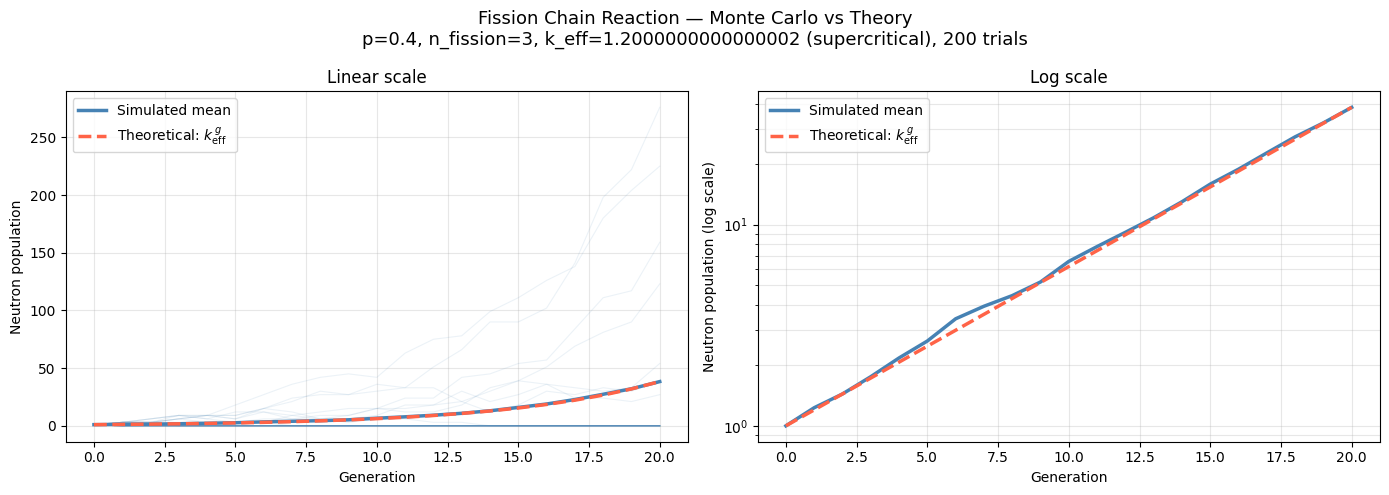

Plot saved.


In [15]:
generations = np.arange(G + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Fission Chain Reaction — Monte Carlo vs Theory\n"
    f"p={p}, n_fission={n_fission}, k_eff={k_eff} ({regime}), "
    f"{n_trials} trials",
    fontsize=13
)

# ── Left plot: linear scale ────────────────────────────────────────
ax = axes[0]
# Plot a sample of individual trials (faint)
for i in range(min(30, n_trials)):
    ax.plot(generations, histories[i], color="steelblue", alpha=0.1, linewidth=0.8)

ax.plot(generations, sim_mean, color="steelblue", linewidth=2.5, label="Simulated mean")
ax.plot(generations, theory, color="tomato", linewidth=2.5,
        linestyle="--", label=r"Theoretical: $k_{\rm eff}^{\,g}$")

ax.set_xlabel("Generation")
ax.set_ylabel("Neutron population")
ax.set_title("Linear scale")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Right plot: log scale (easier to see all regimes) ─────────────
ax2 = axes[1]
ax2.plot(generations, np.maximum(sim_mean, 1e-6),
         color="steelblue", linewidth=2.5, label="Simulated mean")
ax2.plot(generations, np.maximum(theory, 1e-6),
         color="tomato", linewidth=2.5, linestyle="--",
         label=r"Theoretical: $k_{\rm eff}^{\,g}$")

ax2.set_yscale("log")
ax2.set_xlabel("Generation")
ax2.set_ylabel("Neutron population (log scale)")
ax2.set_title("Log scale")
ax2.legend()
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig("fission_phase1_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

## Cell 6 — Regime Comparison

Run all three regimes side by side to visualize the difference.

In [ ]:
regimes = [
    {"label": "Subcritical",  "p": 0.25, "color": "steelblue"},
    {"label": "Critical",     "p": 1/3,  "color": "seagreen"},
    {"label": "Supercritical","p": 0.5,  "color": "tomato"},
]

fig, ax = plt.subplots(figsize=(10, 5))

for r in regimes:
    k = r["p"] * n_fission
    hist = run_trials(r["p"], n_fission, G, n_trials, seed)
    mean = hist.mean(axis=0)
    theory_r = theoretical_curve(k, G)

    ax.plot(generations, mean, color=r["color"], linewidth=2.5,
            label=f"{r['label']} (k={k:.2f}) — simulated")
    ax.plot(generations, theory_r, color=r["color"], linewidth=1.5,
            linestyle="--", alpha=0.6)

ax.set_xlabel("Generation")
ax.set_ylabel("Mean neutron population")
ax.set_title(f"Three Regimes — Simulated (solid) vs Theoretical (dashed)\nn_fission={n_fission}, {n_trials} trials")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale("log")

plt.tight_layout()
plt.savefig("fission_phase1_regimes.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 7 — Error Analysis

How close is our simulation to the theoretical prediction?

We compute the **relative error** per generation:
$$\text{relative error}_g = \frac{|\hat{N}_g - \mathbb{E}[N_g]|}{\mathbb{E}[N_g]}$$

In [ ]:
# Rerun with original parameters
histories = run_trials(p, n_fission, G, n_trials, seed)
sim_mean  = histories.mean(axis=0)
theory    = theoretical_curve(k_eff, G)

# Relative error (skip g=0 since both are exactly 1)
rel_error = np.abs(sim_mean[1:] - theory[1:]) / np.maximum(theory[1:], 1e-10)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(generations[1:], rel_error * 100, color="mediumpurple", alpha=0.8)
ax.set_xlabel("Generation")
ax.set_ylabel("Relative error (%)")
ax.set_title(f"Simulation vs Theory — Relative Error per Generation\n({n_trials} trials, k_eff={k_eff})")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fission_phase1_error.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean relative error across all generations: {rel_error.mean()*100:.2f}%")

## Summary & Next Steps

### What we built
- `simulate_chain()` — Monte Carlo simulation of one fission chain
- `run_trials()` — ensemble of independent chains
- `theoretical_curve()` — closed-form branching process expectation
- Visualizations comparing all three regimes against theory

### Key result
The simulated mean closely tracks $k_{\text{eff}}^g$, confirming the branching process model.

### Phase 2 — Spatial model (planned)
- Assign each neutron a position $(r, \theta, \phi)$ in a sphere of radius $R$
- Replace fixed `p` with a spatially-varying $p(r)$ based on the neutron diffusion flux:
$$\phi(r) \propto \frac{\sin(\pi r / R)}{r}$$
- Neutrons near the surface have higher escape probability → lower effective `p`

### Phase 3 — Future work
- Time-varying $p(r, t)$ as fissile material depletes
- Leads into the neutron transport / diffusion PDE:
$$\frac{1}{v}\frac{\partial \phi}{\partial t} = D\nabla^2\phi - \Sigma_a \phi + S$$
- Numerical PDE methods (finite difference, finite element)